# Proyecto Final — Data Science II

# BTC / DXY / Oro / VIX

## Notebook 01 — Adquisición BTC mediante rangos temporales fijos

Curso: Data Science II — Machine Learning para Ciencia de Datos  
Coderhouse | 2025–2026

---

Este notebook corresponde a la etapa de adquisición definitiva de datos de Bitcoin para el proyecto BTC/DXY/Oro/VIX.

La finalidad de este bloque es construir un dataset reproducible y consistente utilizando rangos temporales fijos, evitando el uso de ventanas dinámicas (`days=365`) que introducen variabilidad temporal entre ejecuciones.

El dataset obtenido en este notebook formará parte de la Fase 1 del pipeline maestro del proyecto.

# Contexto metodológico

Durante la fase exploratoria inicial del proyecto se trabajó con adquisición dinámica utilizando ventanas temporales móviles mediante:

```python
days=365
```

Este enfoque permitió:

- validar conexiones con APIs financieras,
- comprender estructuras JSON,
- construir variables financieras iniciales,
- y desarrollar una exploración preliminar del comportamiento de Bitcoin.

Sin embargo, para la construcción definitiva del dataset del proyecto, se definió una estrategia basada en rangos temporales fijos, con el objetivo de garantizar:

- reproducibilidad,
- estabilidad temporal,
- consistencia multi-activo,
- y trazabilidad metodológica.

# Rango temporal oficial del proyecto

El rango temporal definido para el proyecto será:

| Inicio | Fin |
|---|---|
| 2023-05-06 | 2026-05-06 |

Frecuencia:
- diaria

Duración aproximada:
- ~1096 días (~3 años)

---

## Estrategia de adquisición propuesta

La adquisición inicial se planteará mediante requests anuales independientes sobre el rango temporal oficial del proyecto.

| Request | Rango |
|---|---|
| Request 1 | 2023-05-06 → 2024-05-05 |
| Request 2 | 2024-05-06 → 2025-05-05 |
| Request 3 | 2025-05-06 → 2026-05-06 |

El objetivo de esta estrategia es:

- evitar desfases temporales,
- controlar la reproducibilidad del dataset,
- y mantener consistencia metodológica entre futuras adquisiciones multi-activo.

# Objetivos de este notebook

Este notebook tiene como objetivos:

1. Adquirir datos históricos de Bitcoin mediante rangos temporales fijos.
2. Validar consistencia estructural del JSON recibido desde CoinGecko.
3. Construir datasets parciales por request anual.
4. Estandarizar columnas y tipos de datos.
5. Concatenar y ordenar cronológicamente los bloques temporales.
6. Validar duplicados, gaps temporales y consistencia de fechas.
7. Generar el dataset base definitivo de BTC para etapas posteriores del pipeline.

In [1]:
import requests
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import os

# 1. Request 1 — BTC (2023-05-06 → 2024-05-05)

Primera adquisición histórica fija de Bitcoin para el dataset definitivo del proyecto.

Este bloque corresponde al período:

- Inicio: 2023-05-06
- Fin: 2024-05-05

Objetivos específicos de esta request:

- validar adquisición mediante timestamps fijos,
- inspeccionar consistencia estructural del JSON,
- verificar cobertura temporal,
- y generar el primer bloque anual del dataset BTC definitivo.

In [2]:
url = 'https://api.coingecko.com/api/v3/coins/bitcoin/market_chart/range'

#### Paso 1 - Fijar rango temporal

In [3]:
start_date_1 = datetime(2023, 5, 6)
end_date_1 = datetime(2024, 5, 6)

In [4]:
start_timestamp_1 = int(start_date_1.timestamp())
end_timestamp_1 = int(end_date_1.timestamp())

In [5]:
start_timestamp_1

1683342000

In [6]:
end_timestamp_1

1714964400

#### Paso 2 - Crear los parámetros

In [7]:
params_1 = {
    'vs_currency': 'usd',
    'from': start_timestamp_1,
    'to': end_timestamp_1
}

#### Paso 3 - Hacer la primer petisión a la API utilizando los parámetros fijados

In [8]:
response_1 = requests.get(url,params=params_1)

#### Paso 4 - Validación de respuesta

In [9]:
response_1.status_code

401

In [10]:
response_1.text

'{"error":{"status":{"timestamp":"2026-05-21T19:58:25.219+00:00","error_code":10012,"error_message":"Your request exceeds the allowed time range. Public API users are limited to querying historical data within the past 365 days. Upgrade to a paid plan to enjoy full historical data access: https://www.coingecko.com/en/api/pricing. "}}}'

## 2. Cambio de fuente para adquisición definitiva

Durante la adquisición por rangos fijos se detectó que la API pública gratuita de CoinGecko limita las consultas históricas a los últimos 365 días. Dado que el proyecto requiere cobertura completa y reproducible del rango temporal oficial definido, se decidió migrar la adquisición definitiva de BTC hacia Yahoo Finance mediante la librería `yfinance`.

Esta decisión mantiene el objetivo metodológico del pipeline: reproducibilidad, estabilidad temporal y cobertura completa del período 2023-05-06 → 2026-05-06.

In [11]:
btc_df = yf.download(
    "BTC-USD",
    start="2023-05-06",
    end="2026-05-07",
    interval="1d"
)

[*********************100%***********************]  1 of 1 completed


In [12]:
btc_df.head()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2023-05-06,28904.623047,29820.126953,28468.966797,29538.859375,15913866714
2023-05-07,28454.978516,29157.517578,28441.367188,28901.623047,11301355486
2023-05-08,27694.273438,28663.271484,27310.134766,28450.457031,19122903752
2023-05-09,27658.775391,27821.400391,27375.601562,27695.068359,14128593256
2023-05-10,27621.755859,28322.687500,26883.669922,27654.636719,20656025026


In [13]:
btc_df.tail()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2026-05-02,78657.250000,79119.789062,78031.960938,78177.750000,16761531851
2026-05-03,78538.226562,79402.359375,78073.078125,78656.726562,20544392639
2026-05-04,79827.906250,80742.359375,78217.960938,78540.289062,54325085296
2026-05-05,80927.054688,81751.453125,79787.578125,79823.531250,39700107376
2026-05-06,81427.531250,82792.210938,80751.023438,80930.734375,41751540000


In [14]:
btc_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1097 entries, 2023-05-06 to 2026-05-06
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, BTC-USD)   1097 non-null   float64
 1   (High, BTC-USD)    1097 non-null   float64
 2   (Low, BTC-USD)     1097 non-null   float64
 3   (Open, BTC-USD)    1097 non-null   float64
 4   (Volume, BTC-USD)  1097 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 51.4 KB


# 3. Limpieza estructural del dataset BTC

Yahoo Finance devuelve las columnas del dataset utilizando una estructura MultiIndex, incorporando simultáneamente:

- tipo de variable financiera,
- y ticker del activo.

Para simplificar las etapas posteriores del pipeline (integración, feature engineering, EDA y modelado), se realizará una estandarización de columnas hacia una estructura plana y explícita.

In [15]:
btc_df.columns

MultiIndex([( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD')],
           names=['Price', 'Ticker'])

In [16]:
btc_df.columns = btc_df.columns.droplevel(1)

In [17]:
btc_df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2023-05-06,28904.623047,29820.126953,28468.966797,29538.859375,15913866714
2023-05-07,28454.978516,29157.517578,28441.367188,28901.623047,11301355486
2023-05-08,27694.273438,28663.271484,27310.134766,28450.457031,19122903752
2023-05-09,27658.775391,27821.400391,27375.601562,27695.068359,14128593256
2023-05-10,27621.755859,28322.687500,26883.669922,27654.636719,20656025026


In [18]:
btc_df.index

DatetimeIndex(['2023-05-06', '2023-05-07', '2023-05-08', '2023-05-09',
               '2023-05-10', '2023-05-11', '2023-05-12', '2023-05-13',
               '2023-05-14', '2023-05-15',
               ...
               '2026-04-27', '2026-04-28', '2026-04-29', '2026-04-30',
               '2026-05-01', '2026-05-02', '2026-05-03', '2026-05-04',
               '2026-05-05', '2026-05-06'],
              dtype='datetime64[s]', name='Date', length=1097, freq=None)

# 4. Validación estructural del dataset BTC

Antes de continuar con la construcción de features y análisis exploratorio, se realizan validaciones básicas de integridad estructural sobre el dataset adquirido.

Las siguientes verificaciones buscan confirmar:

- consistencia temporal,
- ausencia de duplicados,
- continuidad diaria del rango,
- y coherencia general de la estructura temporal del dataset.

In [19]:
print("=== VALIDACIÓN ESTRUCTURAL BTC ===")

print(f"Shape del dataset: {btc_df.shape}")

print(
    f"Rango temporal: "
    f"{btc_df.index.min().date()} "
    f"→ "
    f"{btc_df.index.max().date()}"
)

print(
    f"Orden cronológico correcto: "
    f"{btc_df.index.is_monotonic_increasing}"
)

print(
    f"Duplicados temporales: "
    f"{btc_df.index.duplicated().sum()}"
)

print(
    f"Gaps temporales detectados: "
    f"{(btc_df.index.to_series().diff().dropna() != pd.Timedelta(days=1)).sum()}"
)

=== VALIDACIÓN ESTRUCTURAL BTC ===
Shape del dataset: (1097, 5)
Rango temporal: 2023-05-06 → 2026-05-06
Orden cronológico correcto: True
Duplicados temporales: 0
Gaps temporales detectados: 0


# 5. Construcción inicial de features financieras

Una vez validada la integridad estructural y temporal del dataset BTC, se procederá a construir las primeras variables financieras derivadas.

Estas variables permitirán:

- modelar comportamiento del activo,
- medir cambios relativos de precio,
- capturar incertidumbre temporal,
- y representar tendencias suavizadas del mercado.

Las primeras features construidas serán:

- retorno porcentual diario,
- volatilidad rolling de 7 días,
- y media móvil de 7 días.

### 5.1. Retorno porcentual diario

In [20]:
btc_df['return'] = btc_df['Close'].pct_change()

### 5.2. Volatilidad rolling de 7 días

In [21]:
btc_df['volatility_7d'] = btc_df['return'].rolling(window=7).std()

### 5.3. Media móvil de 7 días

In [22]:
btc_df['ma_7d'] = btc_df['Close'].rolling(window=7).mean()

In [23]:
btc_df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'return', 'volatility_7d',
       'ma_7d'],
      dtype='str', name='Price')

In [24]:
btc_df.columns.name = None

# 6. - Validación de features y valores faltantes

Luego de construir las primeras variables financieras derivadas, se validan los valores faltantes generados por operaciones temporales como:

- `pct_change()`
- y ventanas rolling (`rolling()`).

Los NaN esperados forman parte natural de la construcción de features temporales y deben verificarse explícitamente antes de continuar el pipeline.

In [25]:
print("=== VALIDACIÓN DE NaN ===")

print(
    f"NaN en return: "
    f"{btc_df['return'].isna().sum()}"
)

print(
    f"NaN en volatility_7d: "
    f"{btc_df['volatility_7d'].isna().sum()}"
)

print(
    f"NaN en ma_7d: "
    f"{btc_df['ma_7d'].isna().sum()}"
)

=== VALIDACIÓN DE NaN ===
NaN en return: 1
NaN en volatility_7d: 7
NaN en ma_7d: 6


# 7. Exploratory Data Analysis (EDA)

Una vez completada la adquisición, limpieza y construcción inicial de features financieras, se procede a realizar una exploración visual y estadística del comportamiento histórico de Bitcoin.

Objetivos del EDA:

- analizar evolución temporal del precio,
- inspeccionar comportamiento de retornos,
- observar períodos de alta volatilidad,
- identificar tendencias generales,
- y validar coherencia visual de las features construidas.

Esta etapa no busca todavía modelar ni predecir, sino comprender estructuralmente el comportamiento del activo dentro del rango temporal definido.

### 7.1. BTC Close Price

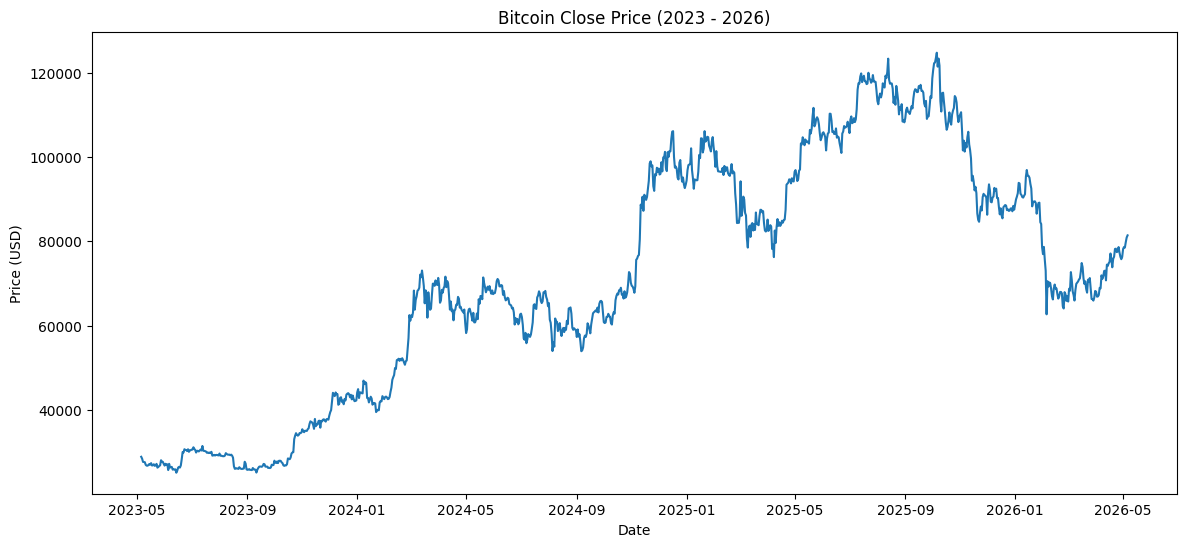

In [26]:
plt.figure(figsize=(14,6))

plt.plot(btc_df.index, btc_df['Close'])

plt.title('Bitcoin Close Price (2023 - 2026)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')

plt.show()

### Interpretación inicial — Precio histórico de BTC

El comportamiento histórico de Bitcoin dentro del rango 2023-05-06 → 2026-05-06 muestra una tendencia alcista general de largo plazo, aunque acompañada por períodos de alta volatilidad y movimientos bruscos de precio.

Se observan:

- impulsos alcistas pronunciados,
- zonas de consolidación temporal,
- y fuertes correcciones intermedias.

Esto sugiere que el activo no mantiene una trayectoria lineal estable, sino que alterna entre distintos regímenes de comportamiento.

A pesar de que el precio final del período es significativamente superior al inicial, existen subperíodos donde BTC presenta comportamiento lateral o bajista en temporalidades más pequeñas.

También se identifican zonas donde el precio retorna aproximadamente a rangos previamente observados luego de atravesar ciclos de alta volatilidad, lo que evidencia que activos con precios finales similares pueden presentar estructuras internas de riesgo completamente distintas.

La visualización confirma además la necesidad de incorporar métricas adicionales al precio bruto, como:

- retornos porcentuales,
- volatilidad rolling,
- drawdowns,
- y análisis de regímenes de mercado,

ya que el precio de cierre por sí solo no describe completamente el comportamiento estadístico del activo.

### 7.2. BTC Daily Returns

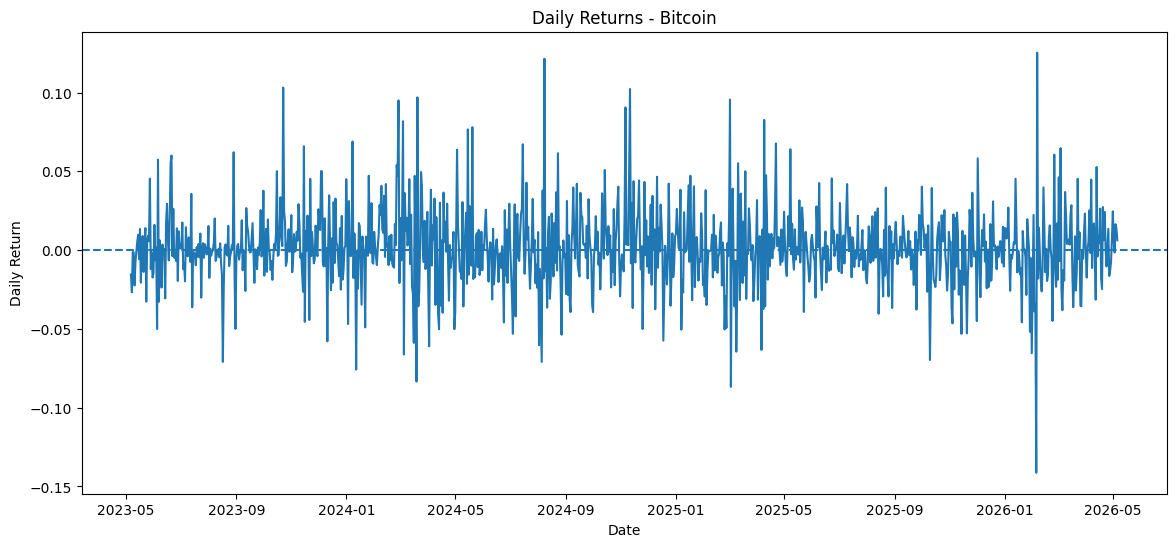

In [27]:
plt.figure(figsize=(14,6))

plt.plot(btc_df.index, btc_df['return'])

plt.axhline(0, linestyle='--')

plt.title('Daily Returns - Bitcoin')
plt.xlabel('Date')
plt.ylabel('Daily Return')

plt.show()

### Interpretación inicial — Retornos diarios de BTC

La serie de retornos diarios muestra un comportamiento fuertemente oscilante alrededor de cero, alternando constantemente entre retornos positivos y negativos.

Se observan:

- spikes positivos superiores al 10%,
- caídas cercanas al -15%,
- y períodos donde los movimientos extremos ocurren en ventanas temporales muy cortas.

Aunque este nivel de variación sería extremadamente alto para activos tradicionales como índices bursátiles, bonos u oro, dentro del contexto de Bitcoin representa un comportamiento posible y coherente con la naturaleza históricamente volátil del activo.

La visualización también permite identificar agrupamientos de volatilidad, donde períodos de movimientos intensos tienden a concentrarse temporalmente, sugiriendo posibles cambios de régimen de mercado.

El gráfico evidencia además que el precio final del activo no resume completamente su comportamiento interno, ya que períodos con retornos diarios extremos pueden terminar convergiendo posteriormente hacia rangos de precios similares.

Esto refuerza la necesidad de incorporar métricas adicionales al precio bruto, especialmente variables relacionadas con:

- volatilidad,
- dispersión,
- drawdowns,
- y estabilidad temporal.

### 7.3. BTC 7-Day Rolling Volatility

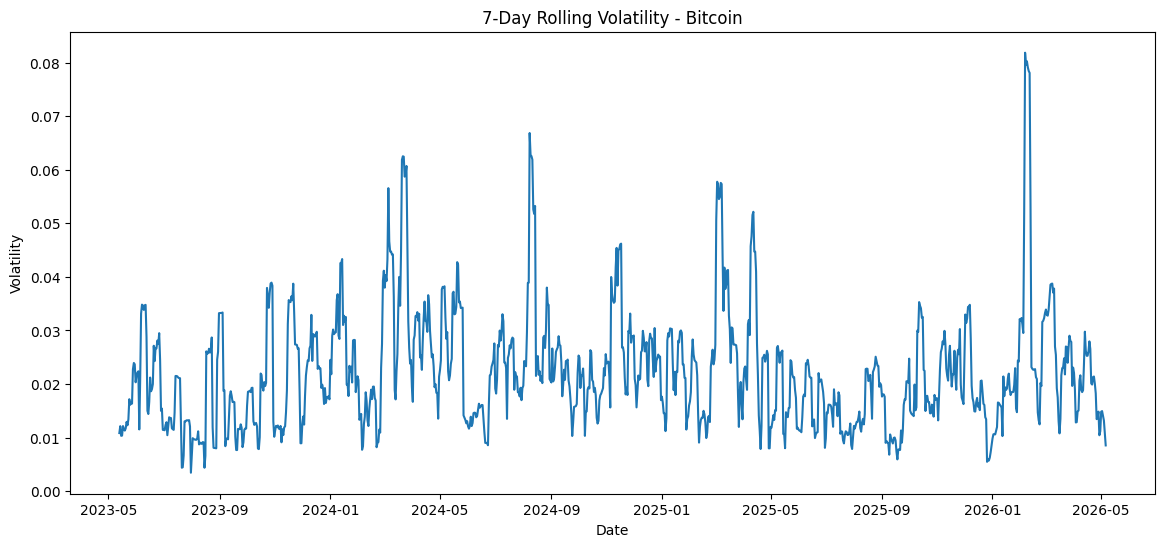

In [28]:
plt.figure(figsize=(14,6))

plt.plot(btc_df.index, btc_df['volatility_7d'])

plt.title('7-Day Rolling Volatility - Bitcoin')
plt.xlabel('Date')
plt.ylabel('Volatility')

plt.show()

### Interpretación inicial — Volatilidad rolling de 7 días

La volatilidad rolling de 7 días permite observar la intensidad y dispersión reciente de los retornos diarios de BTC.

A diferencia del gráfico de retornos, esta métrica no representa dirección de mercado, sino nivel de turbulencia y variabilidad temporal.

Se observan:

- picos abruptos de volatilidad,
- agrupamientos temporales de estrés,
- y períodos relativamente más estables entre episodios de fuerte movimiento.

La visualización muestra que Bitcoin no solo presenta movimientos amplios, sino también cambios extremadamente rápidos en ventanas temporales cortas, donde la volatilidad puede incrementarse significativamente en cuestión de pocos días.

Esto sugiere la presencia de distintos regímenes de mercado, alternando entre:

- fases relativamente calmadas,
- y períodos de alta inestabilidad.

También se observa persistencia temporal de volatilidad, donde episodios de movimientos extremos tienden a mantener elevada la incertidumbre durante varios días consecutivos.

La métrica rolling permite suavizar shocks individuales y representar de forma más estable el comportamiento reciente del riesgo del activo.

### 7.4. BTC Price and 7-Day Moving Average

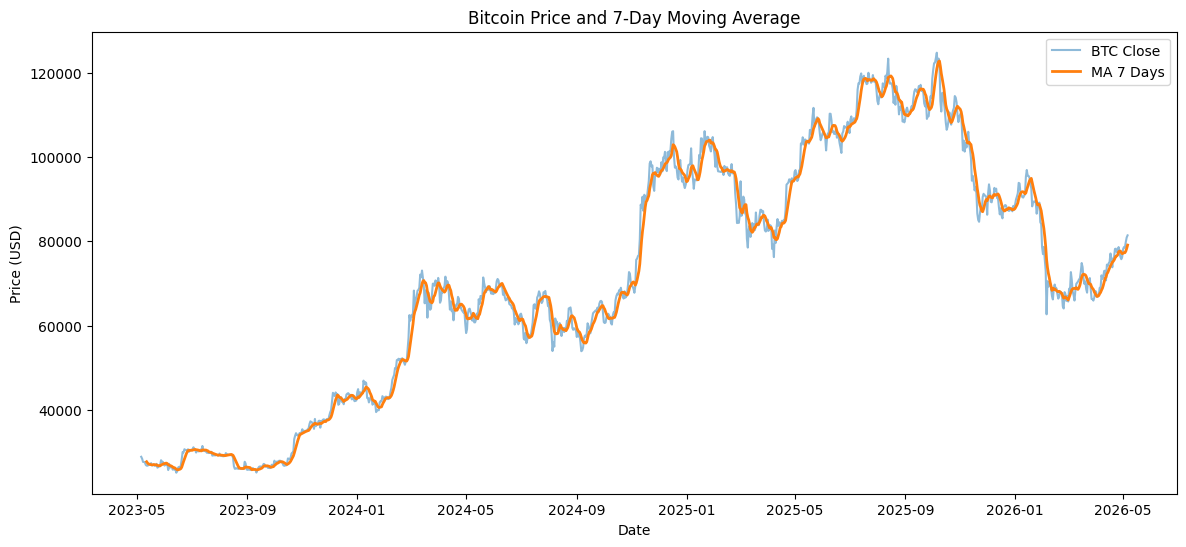

In [29]:
plt.figure(figsize=(14,6))

plt.plot(
    btc_df.index,
    btc_df['Close'],
    alpha=0.5,
    label='BTC Close'
)

plt.plot(
    btc_df.index,
    btc_df['ma_7d'],
    linewidth=2,
    label='MA 7 Days'
)

plt.title('Bitcoin Price and 7-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price (USD)')

plt.legend()

plt.show()

### Interpretación inicial — Media móvil de 7 días

La media móvil de 7 días permite observar una versión suavizada del comportamiento del precio de BTC, reduciendo parte del ruido generado por las oscilaciones diarias.

A diferencia del precio de cierre real, la media móvil:

- responde más lentamente,
- suaviza movimientos abruptos,
- y representa de forma más estable la dirección reciente del mercado.

La visualización muestra que la MA acompaña correctamente las tendencias generales del activo, tanto en períodos alcistas como bajistas, aunque con un retraso temporal natural producto de la ventana rolling utilizada.

También se observa que, durante episodios de movimientos extremos, el precio tiende a separarse temporalmente de la media móvil, reflejando momentos de aceleración, euforia o estrés de mercado.

La diferencia entre precio y media móvil permite representar visualmente el desacople entre:

- comportamiento instantáneo del mercado,
- y tendencia promedio reciente.

La métrica funciona como una herramienta de suavización temporal y no como predictor directo de comportamiento futuro.

# 7.5. Conclusiones preliminares del EDA de BTC

El análisis exploratorio inicial de Bitcoin permitió identificar múltiples características estructurales relevantes para las siguientes etapas del pipeline.

Principales observaciones:

- tendencia alcista general en el horizonte completo 2023-2026,
- alta volatilidad estructural del activo,
- fuerte sensibilidad a cambios de corto plazo,
- presencia de agrupamientos temporales de volatilidad,
- coexistencia entre tendencias globales y movimientos locales caóticos,
- y diferencias significativas entre precio instantáneo y tendencia suavizada.

Las visualizaciones también evidencian que el precio de cierre por sí solo no resulta suficiente para describir completamente el comportamiento del activo, justificando la incorporación de features derivadas como:

- retornos,
- volatilidad rolling,
- medias móviles,
- drawdowns,
- y futuros análisis de regímenes de mercado.

El bloque EDA inicial valida además la coherencia estructural y temporal del dataset adquirido, dejando preparado el entorno para etapas posteriores de integración multi-activo y modelado analítico.

# 8. Export del dataset procesado

Luego de finalizar la adquisición, validación y construcción inicial de features, el dataset procesado de BTC será exportado hacia la carpeta `data/processed/`.

Este archivo funcionará como input reutilizable para las siguientes etapas del pipeline multi-activo del proyecto.

In [30]:
PROJECT_PATH = (
    r"C:\DS2_BTC_DXY_ORO_VIX"
)

In [31]:
processed_path = os.path.join(
    PROJECT_PATH,
    "data",
    "processed"
)

os.makedirs(processed_path, exist_ok=True)

btc_df.to_csv(
    os.path.join(
        processed_path,
        "btc_processed.csv"
    ),
    encoding="utf-8-sig"
)

print("=== EXPORT FINALIZADO ===")

print("Archivo exportado correctamente hacia:")

print(
    os.path.join(
        processed_path,
        "btc_processed.csv"
    )
)

=== EXPORT FINALIZADO ===
Archivo exportado correctamente hacia:
C:\Users\amilc\OneDrive\DATA SCIENCE II\PROYECTO FINAL DS 2\DS2_BTC_DXY_ORO_VIX\data\processed\btc_processed.csv
